<a href="https://colab.research.google.com/github/anshugupta742/data-analytics-projects/blob/main/Driver_Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Setup**

In [ ]:
import subprocess, sys
try:
    import dlib
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dlib"])
    import dlib

import os, re, glob, random, shutil, time, threading
from collections import deque
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, roc_curve,
                             precision_recall_curve, roc_auc_score, average_precision_score)

print("TensorFlow:", tf.__version__, "| OpenCV:", cv2.__version__, "| dlib:", dlib.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0 | OpenCV: 5.0.0 | dlib: 19.24.6
GPU available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob
glob.glob('/content/drive/MyDrive/dataset (2).zip', recursive=True)

['/content/drive/MyDrive/dataset (2).zip']

In [ ]:
import shutil
shutil.unpack_archive("/content/drive/MyDrive/dataset (2).zip", "/content/ddd_manual")

In [ ]:
# ----------------------------- Configuration (change things here, not deep in the code) -----------------------------
SEED          = 42
IMG_SIZE      = (128, 128)      # (height, width) fed to the network
BATCH_SIZE    = 32
VAL_SPLIT     = 0.15

USE_DLIB_CROP = True
CROP_MARGIN   = 0.15            # extra context around the detected face box (fraction of box size)
DLIB_UPSAMPLE = 1               # 0 = fast. Use 1 if many faces are missed (slower, finds smaller faces)

EPOCHS_P1, LR_P1 = 15, 1e-3     # phase 1: frozen base, train the new head
EPOCHS_P2, LR_P2 = 15, 1e-5     # phase 2: fine-tuning with a much smaller learning rate
FINE_TUNE_AT     = 100          # MobileNetV2 has 154 layers: layers >= 100 are unfrozen in phase 2

TARGET_RECALL = 0.95            # safety requirement used to choose the decision threshold (on validation data)
N_TFLITE_EVAL = 2000            # number of random test images used to compare Keras vs TFLite variants

DRIVE_FILE_ID       = "1Wlaeph3x-txoxEEa8J9sv0jdg2hcKo4N"
DATA_ROOT_OVERRIDE  = "/content/ddd_manual/dataset"

WORK_DIR   = "/content/work"
CROP_ROOT  = os.path.join(WORK_DIR, "ddd_cropped")
MODEL_DIR  = os.path.join(WORK_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
CLASS_NAMES = ["non_drowsy", "drowsy"]      # index 0 = Non-Drowsy, index 1 = Drowsy (matches the dataset description)

In [ ]:
import subprocess
print(subprocess.run(["find", "/content/ddd_manual", "-maxdepth", "4"], capture_output=True, text=True).stdout)

/content/ddd_manual
/content/ddd_manual/dataset.zip



In [ ]:
import shutil
shutil.unpack_archive("/content/ddd_manual/dataset.zip", "/content/ddd_manual")

import subprocess
print(subprocess.run(["find", "/content/ddd_manual", "-maxdepth", "4"], capture_output=True, text=True).stdout)

/content/ddd_manual
/content/ddd_manual/dataset.zip
/content/ddd_manual/dataset
/content/ddd_manual/dataset/.DS_Store
/content/ddd_manual/dataset/test
/content/ddd_manual/dataset/test/drowsy
/content/ddd_manual/dataset/test/drowsy/ZB1225.png
/content/ddd_manual/dataset/test/drowsy/T0010.png
/content/ddd_manual/dataset/test/drowsy/L0493.png
/content/ddd_manual/dataset/test/drowsy/P0334.png
/content/ddd_manual/dataset/test/drowsy/E0119.png
/content/ddd_manual/dataset/test/drowsy/L0412.png
/content/ddd_manual/dataset/test/drowsy/U0174.png
/content/ddd_manual/dataset/test/drowsy/M0585.png
/content/ddd_manual/dataset/test/drowsy/A1001.png
/content/ddd_manual/dataset/test/drowsy/P0967.png
/content/ddd_manual/dataset/test/drowsy/L0806.png
/content/ddd_manual/dataset/test/drowsy/V0624.png
/content/ddd_manual/dataset/test/drowsy/J0087.png
/content/ddd_manual/dataset/test/drowsy/J0120.png
/content/ddd_manual/dataset/test/drowsy/P0728.png
/content/ddd_manual/dataset/test/drowsy/ZC0621.png
/conten

#**Loading and Inspecting the Data**

In [ ]:
import gdown, zipfile

def locate_dataset(root):
    """Find the directory that contains both a 'train' and a 'test' folder (case-insensitive)."""
    for dp, dirs, _ in os.walk(root):
        m = {d.lower(): d for d in dirs}
        if "train" in m and "test" in m:
            return os.path.join(dp, m["train"]), os.path.join(dp, m["test"])
    raise FileNotFoundError(f"No train/ and test/ folders found under {root}")

if DATA_ROOT_OVERRIDE:
    root = DATA_ROOT_OVERRIDE
else:
    root = os.path.join(WORK_DIR, "raw")
    if not os.path.isdir(root) or not os.listdir(root):
        os.makedirs(root, exist_ok=True)
        archive = os.path.join(WORK_DIR, "ddd_download")
        gdown.download(id=DRIVE_FILE_ID, output=archive, quiet=False)
        shutil.unpack_archive(archive, root)

TRAIN_DIR_RAW, TEST_DIR_RAW = locate_dataset(root)
print("train:", TRAIN_DIR_RAW, "\ntest :", TEST_DIR_RAW)

def norm_name(s):
    return re.sub(r"[^a-z]", "", s.lower())

def class_folders(split_dir):
    m = {}
    for d in os.listdir(split_dir):
        if os.path.isdir(os.path.join(split_dir, d)):
            n = norm_name(d)
            if n == "drowsy": m["drowsy"] = os.path.join(split_dir, d)
            elif n == "nondrowsy": m["non_drowsy"] = os.path.join(split_dir, d)
    assert set(m) == {"drowsy", "non_drowsy"}, f"Unexpected class folders in {split_dir}: {os.listdir(split_dir)}"
    return m

RAW = {"train": class_folders(TRAIN_DIR_RAW), "test": class_folders(TEST_DIR_RAW)}
IMG_EXT = (".jpg", ".jpeg", ".png")
def list_images(d):
    return sorted(p for p in glob.glob(os.path.join(d, "**", "*"), recursive=True) if p.lower().endswith(IMG_EXT))

counts = pd.DataFrame({s: {c: len(list_images(d)) for c, d in RAW[s].items()} for s in RAW}).T
counts["total"] = counts.sum(axis=1)
counts

train: /content/ddd_manual/dataset/train 
test : /content/ddd_manual/dataset/test


,drowsy,non_drowsy,total
train,3750,3750,7500
test,1250,1250,2500


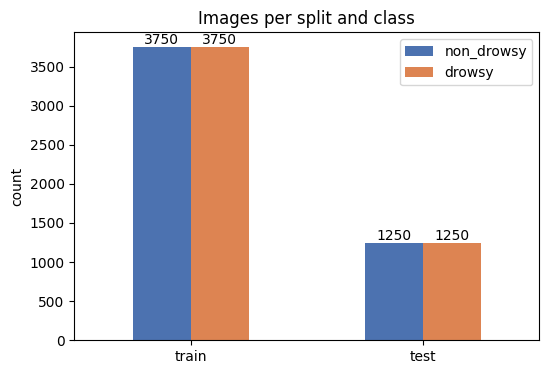

train: drowsy / non_drowsy = 1.00
test: drowsy / non_drowsy = 1.00


In [ ]:
# Class distribution: is the dataset balanced?
ax = counts[["non_drowsy", "drowsy"]].plot(kind="bar", figsize=(6, 4), rot=0, color=["#4c72b0", "#dd8452"])
for c in ax.containers: ax.bar_label(c)
ax.set_title("Images per split and class"); ax.set_ylabel("count"); plt.show()

for s in counts.index:
    ratio = counts.loc[s, "drowsy"] / counts.loc[s, "non_drowsy"]
    print(f"{s}: drowsy / non_drowsy = {ratio:.2f}")

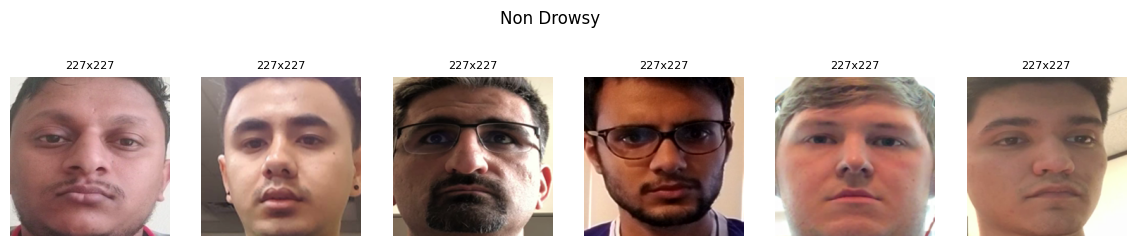

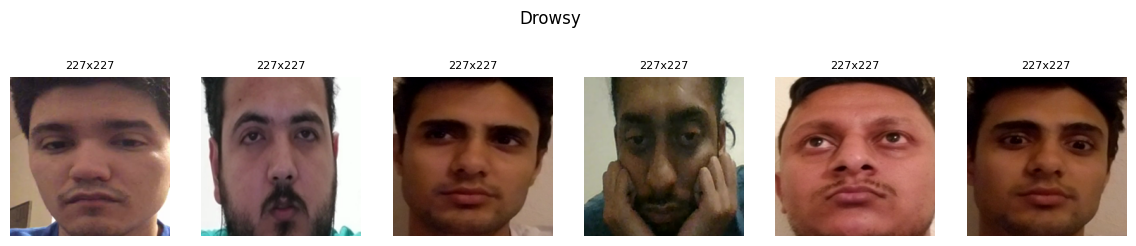

In [ ]:
# Visualise samples from both classes with OpenCV + Matplotlib (OpenCV loads BGR -> convert to RGB for display)
def show_samples(cls, n=6, split="train"):
    paths = random.sample(list_images(RAW[split][cls]), n)
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.8))
    for ax, p in zip(axes, paths):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.set_title(f"{img.shape[1]}x{img.shape[0]}", fontsize=8); ax.axis("off")
    fig.suptitle(cls.replace("_", " ").title(), y=1.02); plt.show()

show_samples("non_drowsy"); show_samples("drowsy")

In [ ]:
# Data quality checks: unreadable files and image-size spread
def is_valid(path):
    try:
        with Image.open(path) as im: im.verify()
        return True
    except Exception:
        return False

all_paths = [p for s in RAW for d in RAW[s].values() for p in list_images(d)]
bad = [p for p in tqdm(all_paths, desc="verifying images") if not is_valid(p)]
print(f"{len(all_paths)} images checked, {len(bad)} unreadable")
for p in bad[:10]: print("  bad:", p)

sizes = pd.DataFrame([cv2.imread(p).shape[:2] for p in random.sample(all_paths, min(600, len(all_paths)))],
                     columns=["height", "width"])
print("\nImage size statistics (600-image sample):"); print(sizes.describe().loc[["min", "mean", "max"]].round(0))

verifying images:   0%|          | 0/10000 [00:00<?, ?it/s]

10000 images checked, 0 unreadable

Image size statistics (600-image sample):
      height  width
min    227.0  227.0
mean   227.0  227.0
max    227.0  227.0


#**Face detection with Dlib**

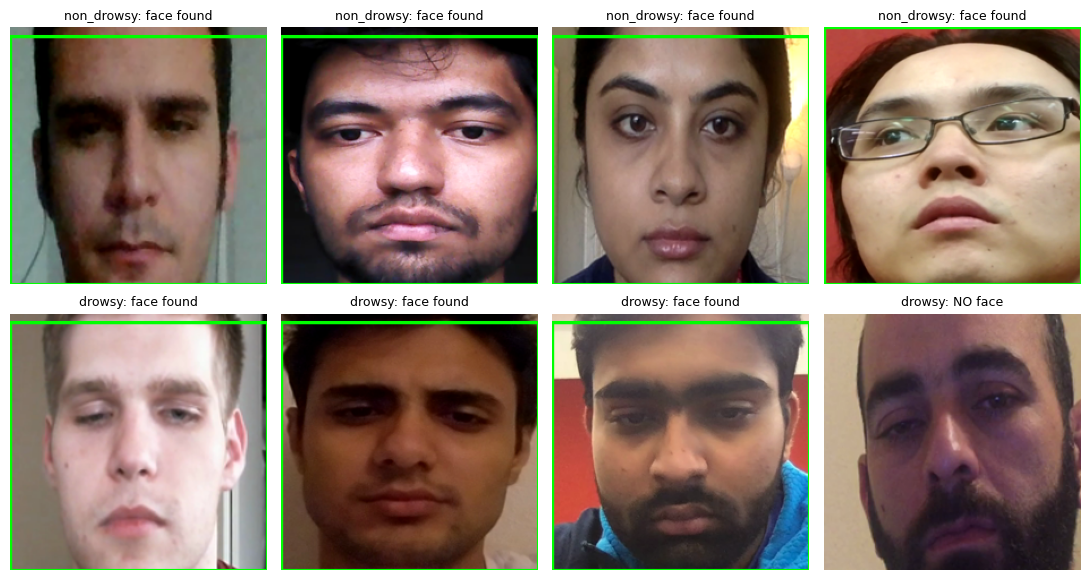

In [ ]:
_local = threading.local()
def get_detector():
    if not hasattr(_local, "det"):                 # one detector per thread
        _local.det = dlib.get_frontal_face_detector()
    return _local.det

def detect_face_box(img_bgr, upsample=DLIB_UPSAMPLE, margin=CROP_MARGIN):
    """Return (x1, y1, x2, y2) of the largest detected face (with margin) or None."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    rects = get_detector()(gray, upsample)
    if len(rects) == 0:
        return None
    r = max(rects, key=lambda r: r.width() * r.height())
    h, w = gray.shape
    mx, my = int(r.width() * margin), int(r.height() * margin)
    x1, y1 = max(0, r.left() - mx), max(0, r.top() - my)
    x2, y2 = min(w, r.right() + mx), min(h, r.bottom() + my)
    return (x1, y1, x2, y2) if (x2 > x1 and y2 > y1) else None

def crop_face(img_bgr):
    box = detect_face_box(img_bgr)
    if box is None:
        return None
    x1, y1, x2, y2 = box
    return img_bgr[y1:y2, x1:x2]

# Visual check: detected box on 4 images per class
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, cls in enumerate(["non_drowsy", "drowsy"]):
    for ax, p in zip(axes[row], random.sample(list_images(RAW["train"][cls]), 4)):
        img = cv2.imread(p); box = detect_face_box(img); vis = img.copy()
        if box: cv2.rectangle(vis, box[:2], box[2:], (0, 255, 0), 2)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax.axis("off")
        ax.set_title(f"{cls}: {'face found' if box else 'NO face'}", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
import shutil
shutil.rmtree(CROP_ROOT, ignore_errors=True)

In [ ]:
DONE_MARK = os.path.join(CROP_ROOT, ".done")

def _process(job):
    src, dst, split, cls = job
    img = cv2.imread(src)
    if img is None:
        return split, cls, "unreadable"
    crop = crop_face(img)
    status = "detected" if crop is not None else "fallback_original"
    cv2.imwrite(dst, crop if crop is not None else img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return split, cls, status

if USE_DLIB_CROP:
    if not os.path.exists(DONE_MARK):
        jobs = []
        for split in RAW:
            for cls, d in RAW[split].items():
                out = os.path.join(CROP_ROOT, split, cls); os.makedirs(out, exist_ok=True)
                for i, p in enumerate(list_images(d)):
                    jobs.append((p, os.path.join(out, f"{i:06d}.jpg"), split, cls))
        with ThreadPoolExecutor(max_workers=os.cpu_count() or 2) as ex:
            results = list(tqdm(ex.map(_process, jobs, chunksize=32), total=len(jobs), desc="Dlib crop"))
        pd.DataFrame(results, columns=["split", "cls", "status"]).to_csv(os.path.join(CROP_ROOT, "crop_report.csv"), index=False)
        open(DONE_MARK, "w").close()

    report = pd.read_csv(os.path.join(CROP_ROOT, "crop_report.csv"))
    print(pd.crosstab([report.split, report.cls], report.status, normalize="index").round(3).mul(100).astype(str) + " %")
    TRAIN_DIR, TEST_DIR = os.path.join(CROP_ROOT, "train"), os.path.join(CROP_ROOT, "test")
    CLASS_DIRS = CLASS_NAMES
else:
    TRAIN_DIR, TEST_DIR = TRAIN_DIR_RAW, TEST_DIR_RAW
    # use the folder names that actually exist on disk, ordered [non_drowsy, drowsy]
    CLASS_DIRS = [os.path.basename(RAW["train"][c]) for c in CLASS_NAMES]

print("\nTraining on:", TRAIN_DIR, "\nTesting on :", TEST_DIR, "\nClass folders (label 0, 1):", CLASS_DIRS)

Dlib crop:   0%|          | 0/10000 [00:00<?, ?it/s]

status           detected     fallback_original
split cls                                      
test  drowsy       93.0 %   7.000000000000001 %
      non_drowsy   94.1 %  5.8999999999999995 %
train drowsy       92.4 %                 7.6 %
      non_drowsy   95.5 %                 4.5 %

Training on: /content/work/ddd_cropped/train 
Testing on : /content/work/ddd_cropped/test 
Class folders (label 0, 1): ['non_drowsy', 'drowsy']


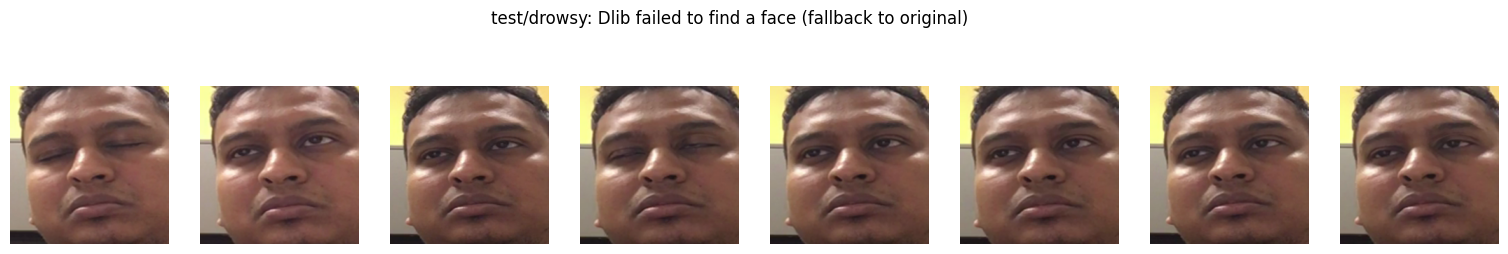

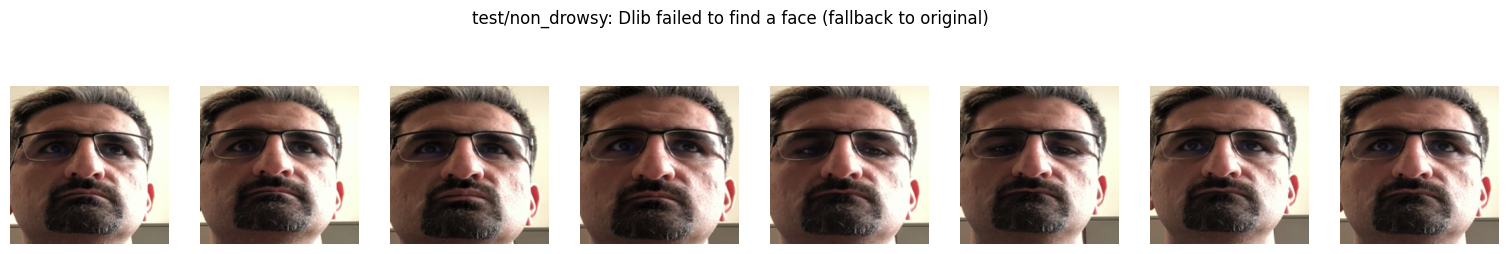

In [ ]:
import matplotlib.pyplot as plt
import cv2

report["local_idx"] = report.groupby(["split", "cls"]).cumcount()

def show_fallbacks(split="test", cls="drowsy", n=8):
    fails = report[(report.split == split) & (report.cls == cls) & (report.status == "fallback_original")]
    src_paths = list_images(RAW[split][cls])
    idx = fails["local_idx"].iloc[:n].tolist()

    fig, axes = plt.subplots(1, len(idx), figsize=(2.4 * len(idx), 2.8))
    for ax, i in zip(axes, idx):
        img = cv2.cvtColor(cv2.imread(src_paths[i]), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis("off")
    fig.suptitle(f"{split}/{cls}: Dlib failed to find a face (fallback to original)", y=1.05)
    plt.show()

show_fallbacks("test", "drowsy")
show_fallbacks("test", "non_drowsy")

#**Preprocessing, Resizing and Data Augmentation**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_ds(directory, subset=None, shuffle=True):
    return tf.keras.utils.image_dataset_from_directory(
        directory, labels="inferred", label_mode="binary", class_names=CLASS_DIRS,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED,
        validation_split=VAL_SPLIT if subset else None, subset=subset)

train_raw = load_ds(TRAIN_DIR, "training")
val_raw   = load_ds(TRAIN_DIR, "validation")
test_raw  = load_ds(TEST_DIR, shuffle=False)      # fixed order so predictions line up with file paths
test_paths = list(test_raw.file_paths)
print("class order (label 0, 1):", train_raw.class_names)

Found 7500 files belonging to 2 classes.
Using 6375 files for training.
Found 7500 files belonging to 2 classes.
Using 1125 files for validation.
Found 2500 files belonging to 2 classes.
class order (label 0, 1): ['non_drowsy', 'drowsy']


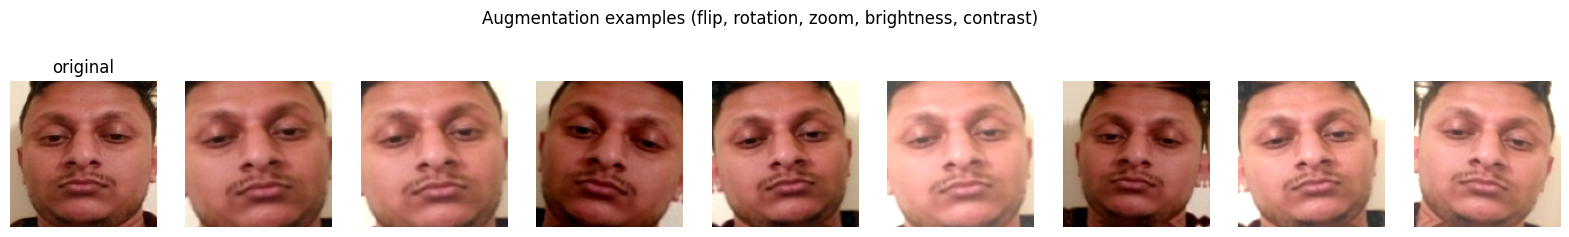

In [ ]:
# Augmentation runs on 0-255 pixel values, then we scale to 0-1
augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),         # +-4% of a full turn = about +-14 degrees
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.2),
], name="augmentation")

def to_unit(x, y):                       # 0-255 -> 0-1
    return tf.cast(x, tf.float32) / 255.0, y

def augment(x, y):
    x = augmenter(tf.cast(x, tf.float32), training=True)
    return tf.clip_by_value(x, 0.0, 255.0) / 255.0, y

train_ds = train_raw.map(augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_raw.map(to_unit, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_raw.map(to_unit, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Visual check: one image, 8 random augmentations
x_batch, _ = next(iter(train_raw))
fig, axes = plt.subplots(1, 9, figsize=(20, 2.6))
axes[0].imshow(x_batch[0].numpy().astype("uint8")); axes[0].set_title("original"); axes[0].axis("off")
for ax in axes[1:]:
    aug = augmenter(tf.expand_dims(tf.cast(x_batch[0], tf.float32), 0), training=True)[0]
    ax.imshow(np.clip(aug.numpy(), 0, 255).astype("uint8")); ax.axis("off")
plt.suptitle("Augmentation examples (flip, rotation, zoom, brightness, contrast)", y=1.05); plt.show()

In [ ]:
# Class weights: protects against class imbalance (harmless if the data is balanced)
n_ndr, n_dr = counts.loc["train", "non_drowsy"], counts.loc["train", "drowsy"]
total = n_ndr + n_dr
CLASS_WEIGHT = {0: total / (2 * n_ndr), 1: total / (2 * n_dr)}
print("class weights:", {k: round(v, 3) for k, v in CLASS_WEIGHT.items()})
print(n_ndr, n_dr)

class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
3750 3750


#**Model building: transfer learning with MobileNetV2**

In [ ]:
def build_model():
    base = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False                                   # phase 1: frozen
    inputs = layers.Input(IMG_SIZE + (3,), name="image_0_1")  # expects pixels in [0, 1]
    x = layers.Rescaling(2.0, offset=-1.0, name="to_minus1_1")(inputs)   # -> [-1, 1] as MobileNetV2 expects
    x = base(x, training=False)                              # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="p_drowsy")(x)
    return tf.keras.Model(inputs, outputs, name="drowsiness_mobilenetv2"), base

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])

def make_callbacks(ckpt_path):
    return [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0)]

model, base = build_model()
compile_model(model, LR_P1)
n_train = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
n_total = model.count_params()
print(f"trainable parameters (phase 1): {n_train:,} of {n_total:,}")
model.summary(show_trainable=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
trainable parameters (phase 1): 164,097 of 2,422,081


Model: "drowsiness_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ image_0_1 (InputLayer)      │ (None, 128, 128, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ to_minus1_1 (Rescaling)     │ (None, 128, 128, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_128        │ (None, 4, 4, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 128)           │    163,968 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ p_drowsy (Dense)            │ (None, 1)             │        129 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ------------------------------ Phase 1: train the head (base frozen) ------------------------------
CKPT1 = os.path.join(MODEL_DIR, "phase1_best.keras")
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_P1, class_weight=CLASS_WEIGHT,
                  callbacks=make_callbacks(CKPT1), verbose=2)

Epoch 1/15
200/200 - 52s - 262ms/step - accuracy: 0.7920 - auc: 0.8747 - loss: 0.4421 - precision: 0.7924 - recall: 0.7904 - val_accuracy: 0.9476 - val_auc: 0.9908 - val_loss: 0.1875 - val_precision: 0.9396 - val_recall: 0.9577 - learning_rate: 0.0010
Epoch 2/15
200/200 - 27s - 136ms/step - accuracy: 0.9114 - auc: 0.9706 - loss: 0.2262 - precision: 0.9174 - recall: 0.9038 - val_accuracy: 0.9671 - val_auc: 0.9979 - val_loss: 0.1026 - val_precision: 0.9447 - val_recall: 0.9930 - learning_rate: 0.0010
Epoch 3/15
200/200 - 28s - 139ms/step - accuracy: 0.9346 - auc: 0.9843 - loss: 0.1650 - precision: 0.9303 - recall: 0.9393 - val_accuracy: 0.9787 - val_auc: 0.9988 - val_loss: 0.0831 - val_precision: 0.9892 - val_recall: 0.9683 - learning_rate: 0.0010
Epoch 4/15
200/200 - 27s - 133ms/step - accuracy: 0.9539 - auc: 0.9912 - loss: 0.1247 - precision: 0.9501 - recall: 0.9579 - val_accuracy: 0.9858 - val_auc: 0.9994 - val_loss: 0.0621 - val_precision: 0.9929 - val_recall: 0.9789 - learning_rate:

In [ ]:
# ------------------------------ Phase 2: fine-tune the last layers with a small learning rate ------------------------------
base.trainable = True
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
compile_model(model, LR_P2)
print(f"trainable parameters (phase 2): {sum(int(np.prod(w.shape)) for w in model.trainable_weights):,}")

CKPT2 = os.path.join(MODEL_DIR, "phase2_best.keras")
start = hist1.epoch[-1] + 1
hist2 = model.fit(train_ds, validation_data=val_ds, initial_epoch=start, epochs=start + EPOCHS_P2,
                  class_weight=CLASS_WEIGHT, callbacks=make_callbacks(CKPT2), verbose=2)

trainable parameters (phase 2): 2,003,713
Epoch 16/30
200/200 - 53s - 264ms/step - accuracy: 0.9835 - auc: 0.9984 - loss: 0.0448 - precision: 0.9837 - recall: 0.9833 - val_accuracy: 0.9938 - val_auc: 0.9998 - val_loss: 0.0205 - val_precision: 0.9982 - val_recall: 0.9894 - learning_rate: 1.0000e-05
Epoch 17/30
200/200 - 27s - 134ms/step - accuracy: 0.9849 - auc: 0.9989 - loss: 0.0393 - precision: 0.9843 - recall: 0.9855 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0046 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 18/30
200/200 - 26s - 131ms/step - accuracy: 0.9915 - auc: 0.9990 - loss: 0.0261 - precision: 0.9912 - recall: 0.9918 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0035 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 19/30
200/200 - 25s - 123ms/step - accuracy: 0.9925 - auc: 0.9995 - loss: 0.0211 - precision: 0.9912 - recall: 0.9937 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0038 - v

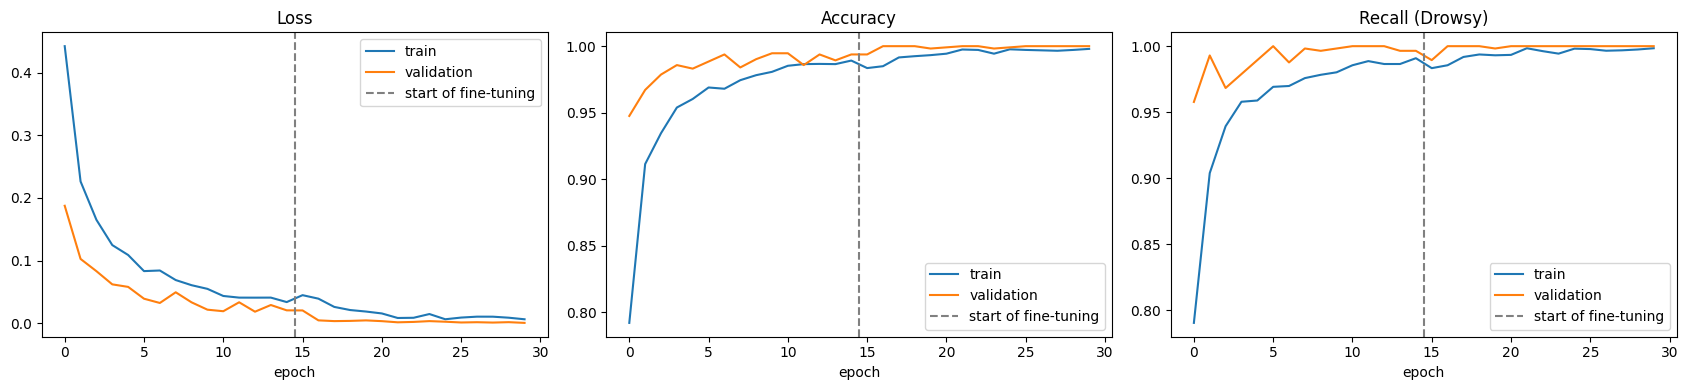

In [ ]:
# Training curves for both phases
def cat(key): return hist1.history[key] + hist2.history[key]
n1 = len(hist1.history["loss"])
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (k, title) in zip(axes, [("loss", "Loss"), ("accuracy", "Accuracy"), ("recall", "Recall (Drowsy)")]):
    ax.plot(cat(k), label="train"); ax.plot(cat("val_" + k), label="validation")
    ax.axvline(n1 - 0.5, color="grey", ls="--", label="start of fine-tuning")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

#**Evaluation on the held-out test set**

In [ ]:
best = tf.keras.models.load_model(CKPT2)               # best fine-tuned weights (lowest validation loss)

def collect_predictions(m, ds):
    ys, ps = [], []
    for x, y in ds:
        ps.append(m.predict_on_batch(x).ravel()); ys.append(y.numpy().ravel())
    return np.concatenate(ys).astype(int), np.concatenate(ps)

y_val,  p_val  = collect_predictions(best, val_ds)
y_test, p_test = collect_predictions(best, test_ds)
assert len(y_test) == len(test_paths)

pred_05 = (p_test >= 0.5).astype(int)
print("=== Test set, default threshold 0.5 ===")
print(classification_report(y_test, pred_05, target_names=["Non-Drowsy", "Drowsy"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, p_test):.4f} | PR-AUC (average precision): {average_precision_score(y_test, p_test):.4f}")

=== Test set, default threshold 0.5 ===
              precision    recall  f1-score   support

  Non-Drowsy     1.0000    0.9992    0.9996      1250
      Drowsy     0.9992    1.0000    0.9996      1250

    accuracy                         0.9996      2500
   macro avg     0.9996    0.9996    0.9996      2500
weighted avg     0.9996    0.9996    0.9996      2500

ROC-AUC: 1.0000 | PR-AUC (average precision): 1.0000


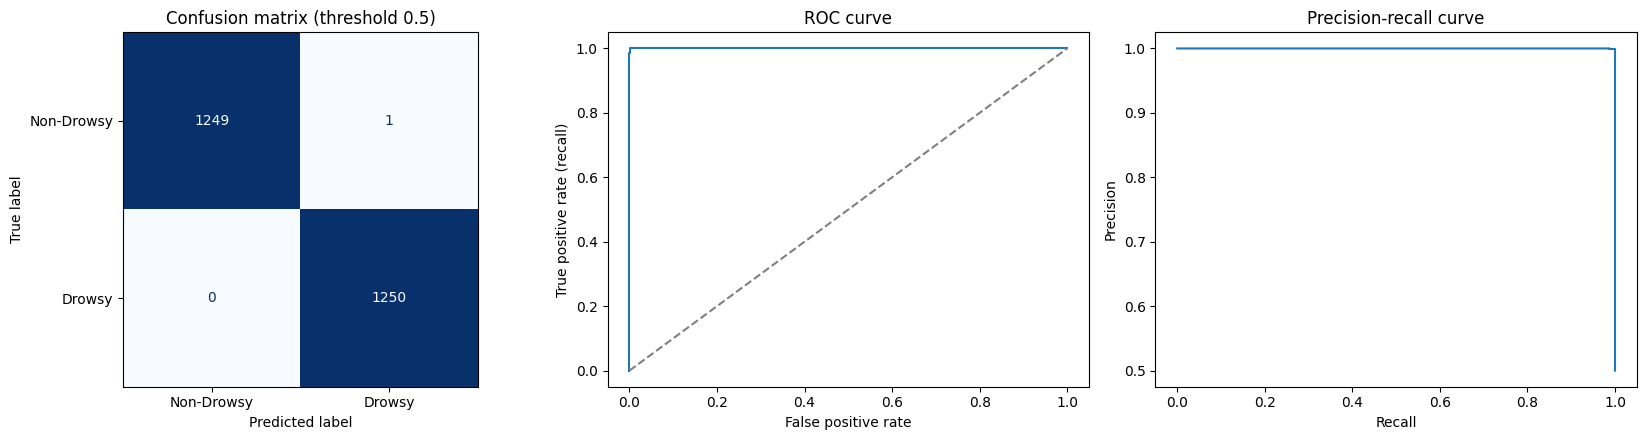

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_05), display_labels=["Non-Drowsy", "Drowsy"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (threshold 0.5)")
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate (recall)"); axes[1].set_title("ROC curve")
pr, rc, _ = precision_recall_curve(y_test, p_test)
axes[2].plot(rc, pr); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision"); axes[2].set_title("Precision-recall curve")
plt.tight_layout(); plt.show()

#**Confidence threshold and Error Analysis**

Chosen threshold (validation, recall >= 0.95): 0.98


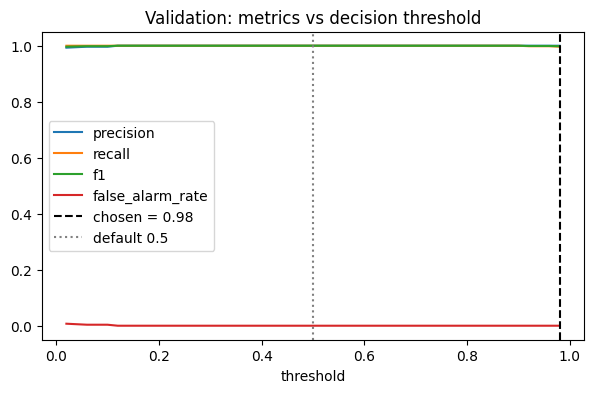

=== Test set, tuned threshold 0.98 ===
              precision    recall  f1-score   support

  Non-Drowsy     0.9913    0.9992    0.9952      1250
      Drowsy     0.9992    0.9912    0.9952      1250

    accuracy                         0.9952      2500
   macro avg     0.9952    0.9952    0.9952      2500
weighted avg     0.9952    0.9952    0.9952      2500



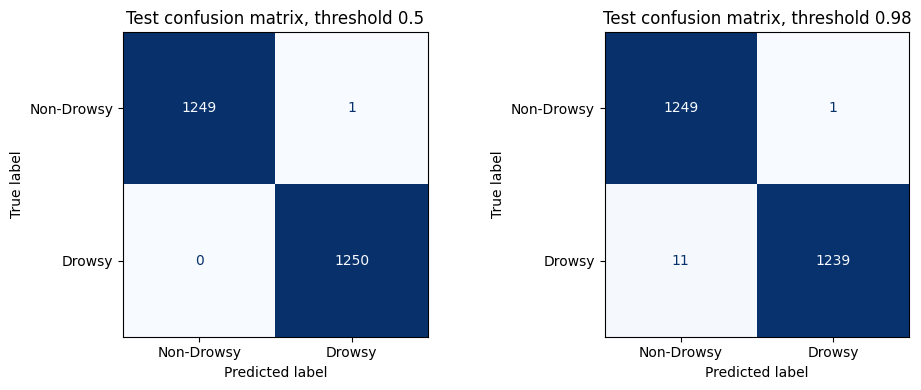

In [ ]:
def threshold_table(y, p, grid=np.linspace(0.02, 0.98, 49)):
    rows = []
    for t in grid:
        pred = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        rows.append(dict(threshold=round(t, 2), precision=precision_score(y, pred, zero_division=0),
                         recall=recall_score(y, pred), f1=f1_score(y, pred),
                         false_alarm_rate=fp / max(fp + tn, 1), missed_drowsy=fn))
    return pd.DataFrame(rows)

val_tab = threshold_table(y_val, p_val)
ok = val_tab[val_tab.recall >= TARGET_RECALL]
THRESHOLD = float(ok.threshold.max()) if len(ok) else float(val_tab.loc[val_tab.recall.idxmax(), "threshold"])
print(f"Chosen threshold (validation, recall >= {TARGET_RECALL}): {THRESHOLD}"
      + ("" if len(ok) else "  [target recall not reachable, using max-recall threshold]"))

plt.figure(figsize=(7, 4))
for c in ["precision", "recall", "f1", "false_alarm_rate"]: plt.plot(val_tab.threshold, val_tab[c], label=c)
plt.axvline(THRESHOLD, color="k", ls="--", label=f"chosen = {THRESHOLD}"); plt.axvline(0.5, color="grey", ls=":", label="default 0.5")
plt.xlabel("threshold"); plt.title("Validation: metrics vs decision threshold"); plt.legend(); plt.show()

pred_thr = (p_test >= THRESHOLD).astype(int)
print(f"=== Test set, tuned threshold {THRESHOLD} ===")
print(classification_report(y_test, pred_thr, target_names=["Non-Drowsy", "Drowsy"], digits=4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pr_, t in zip(axes, [pred_05, pred_thr], [0.5, THRESHOLD]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pr_), display_labels=["Non-Drowsy", "Drowsy"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Test confusion matrix, threshold {t}")
plt.tight_layout(); plt.show()

Missed drowsy drivers (false negatives): 11 images


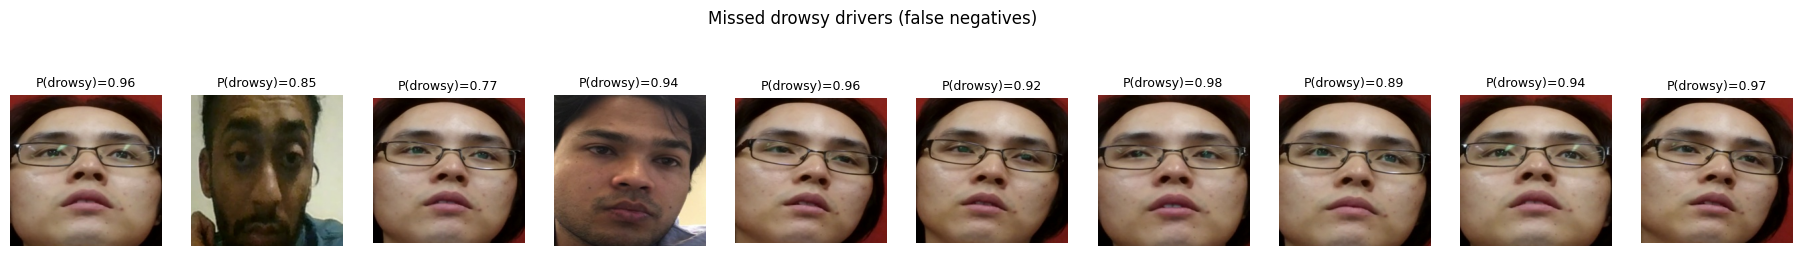

False alarms (false positives): 1 images


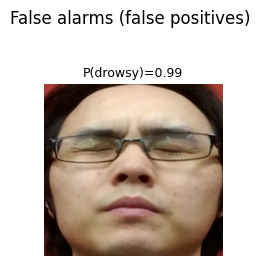

In [ ]:
# Look at the mistakes: what do the missed drowsy drivers (false negatives) and false alarms look like?
def show_errors(mask, title, n=10):
    idx = np.where(mask)[0]
    print(f"{title}: {len(idx)} images")
    if len(idx) == 0: return
    idx = np.random.RandomState(SEED).choice(idx, min(n, len(idx)), replace=False)
    fig, axes = plt.subplots(1, len(idx), figsize=(2.3 * len(idx), 2.9))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(cv2.cvtColor(cv2.imread(test_paths[i]), cv2.COLOR_BGR2RGB)); ax.axis("off")
        ax.set_title(f"P(drowsy)={p_test[i]:.2f}", fontsize=9)
    plt.suptitle(title, y=1.05); plt.show()

show_errors((y_test == 1) & (pred_thr == 0), "Missed drowsy drivers (false negatives)")
show_errors((y_test == 0) & (pred_thr == 1), "False alarms (false positives)")

#**Edge deployment with TensorFlow Lite**

In [ ]:
SAVED_DIR = os.path.join(MODEL_DIR, "saved_model")
shutil.rmtree(SAVED_DIR, ignore_errors=True)
if hasattr(best, "export"): best.export(SAVED_DIR)
else: tf.saved_model.save(best, SAVED_DIR)

def convert(name, configure=None):
    conv = tf.lite.TFLiteConverter.from_saved_model(SAVED_DIR)
    if configure: configure(conv)
    blob = conv.convert()
    path = os.path.join(MODEL_DIR, f"drowsiness_{name}.tflite")
    open(path, "wb").write(blob)
    return path

def cfg_dynamic(c): c.optimizations = [tf.lite.Optimize.DEFAULT]
def cfg_fp16(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]; c.target_spec.supported_types = [tf.float16]
def representative_data():
    for x, _ in train_raw.map(to_unit).take(10):            # 10 batches = 320 real (un-augmented) images
        for i in range(x.shape[0]):
            yield [x[i:i + 1].numpy()]
def cfg_int8(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = representative_data
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

TFLITE = {}
for name, cfg in [("float32", None), ("dynamic_int8", cfg_dynamic), ("float16", cfg_fp16), ("full_int8", cfg_int8)]:
    try:
        TFLITE[name] = convert(name, cfg)
    except Exception as e:
        print(f"[skipped] {name}: {type(e).__name__}: {str(e)[:200]}")

best.save(os.path.join(MODEL_DIR, "drowsiness_full.keras"))
sizes = {"keras (.keras)": os.path.getsize(os.path.join(MODEL_DIR, "drowsiness_full.keras")) / 1e6}
sizes.update({f"tflite {k}": os.path.getsize(v) / 1e6 for k, v in TFLITE.items()})
size_df = pd.DataFrame({"size_MB": sizes}).round(2)
size_df["vs_keras"] = (size_df.size_MB / size_df.size_MB.iloc[0]).round(2)
size_df

Saved artifact at '/content/work/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image_0_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136099265781520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099265779216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266778064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099265779792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099265784208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266778832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266786320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266786512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266773648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136099266778448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

,size_MB,vs_keras
keras (.keras),26.32,1.00
tflite float32,9.52,0.36
tflite dynamic_int8,2.68,0.10
tflite float16,4.80,0.18
tflite full_int8,2.88,0.11


In [ ]:
# Manual OpenCV inference path (this is what would run on the device): BGR -> RGB, optional Dlib crop, resize, 0-1
def load_image(path, dlib_crop=USE_DLIB_CROP):
    img = cv2.imread(path)
    if dlib_crop:
        c = crop_face(img)
        if c is not None: img = c
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_LINEAR)
    return img.astype(np.float32) / 255.0                    # 0-1

class TFLiteClassifier:
    def __init__(self, path):
        self.interp = tf.lite.Interpreter(model_path=path)
        self.interp.allocate_tensors()
        self.inp, self.out = self.interp.get_input_details()[0], self.interp.get_output_details()[0]
    def predict(self, img01):
        self.interp.set_tensor(self.inp["index"], img01[None].astype(np.float32))
        self.interp.invoke()
        return float(self.interp.get_tensor(self.out["index"])[0, 0])

# Random test subset. When USE_DLIB_CROP is True the test images on disk are already cropped, so crop is skipped here.
rng = np.random.RandomState(SEED)
sub_idx = rng.choice(len(test_paths), min(N_TFLITE_EVAL, len(test_paths)), replace=False)
X_sub = np.stack([load_image(test_paths[i], dlib_crop=False) for i in tqdm(sub_idx, desc="loading test subset")])
y_sub = y_test[sub_idx]

rows = []
p_keras = best.predict(X_sub, batch_size=64, verbose=0).ravel()
rows.append(dict(model="keras", **{k: f(y_sub, (p_keras >= THRESHOLD).astype(int)) for k, f in
                                   [("accuracy", lambda a, b: (a == b).mean()), ("precision", precision_score), ("recall", recall_score), ("f1", f1_score)]},
                 ms_per_image=np.nan))
for name, path in TFLITE.items():
    clf = TFLiteClassifier(path)
    for x in X_sub[:5]: clf.predict(x)                       # warm-up
    t0 = time.perf_counter(); probs = np.array([clf.predict(x) for x in X_sub]); dt = (time.perf_counter() - t0) / len(X_sub) * 1000
    pred = (probs >= THRESHOLD).astype(int)
    rows.append(dict(model=f"tflite_{name}", accuracy=(y_sub == pred).mean(), precision=precision_score(y_sub, pred),
                     recall=recall_score(y_sub, pred), f1=f1_score(y_sub, pred), ms_per_image=dt))
tflite_cmp = pd.DataFrame(rows).set_index("model").round(4)
print(f"Evaluated on {len(X_sub)} random test images, threshold = {THRESHOLD} (latency measured on the Colab CPU, a Raspberry Pi will be slower)")
tflite_cmp

loading test subset:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

Evaluated on 2000 random test images, threshold = 0.98 (latency measured on the Colab CPU, a Raspberry Pi will be slower)


,accuracy,precision,recall,f1,ms_per_image
model,,,,,
keras,0.9935,0.9990,0.9880,0.9935,NaN
tflite_float32,0.9935,0.9990,0.9880,0.9935,2.7530
tflite_dynamic_int8,0.9920,0.9990,0.9850,0.9920,7.0230
tflite_float16,0.9945,0.9990,0.9900,0.9945,3.0958
tflite_full_int8,0.9600,0.9946,0.9252,0.9587,4.5694


##**End-to-end inference with the lightweight model**

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Deployed model: drowsiness_dynamic_int8.tflite | threshold 0.98


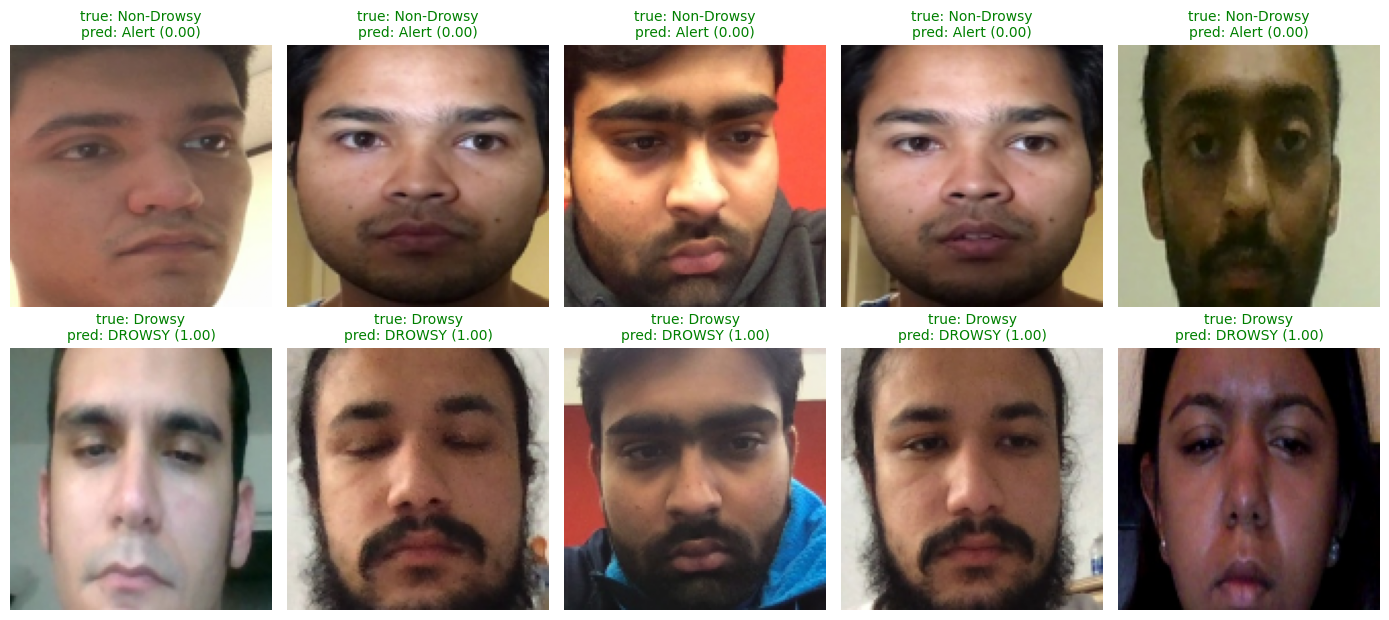

In [ ]:
DEPLOY_MODEL = TFLITE.get("dynamic_int8") or TFLITE["float32"]
clf = TFLiteClassifier(DEPLOY_MODEL)
print("Deployed model:", os.path.basename(DEPLOY_MODEL), f"| threshold {THRESHOLD}")

samples = []
for lab, cls in [(0, "non_drowsy"), (1, "drowsy")]:
    idx = np.where(y_test == lab)[0]
    samples += list(np.random.RandomState(1).choice(idx, 5, replace=False))

fig, axes = plt.subplots(2, 5, figsize=(14, 6.4))
for ax, i in zip(axes.ravel(), samples):
    img = load_image(test_paths[i], dlib_crop=False); p = clf.predict(img)
    label = "DROWSY" if p >= THRESHOLD else "Alert"
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {'Drowsy' if y_test[i] else 'Non-Drowsy'}\npred: {label} ({p:.2f})", fontsize=10,
                 color="green" if (p >= THRESHOLD) == bool(y_test[i]) else "red")
plt.tight_layout(); plt.show()

##**From a single-frame prediction to an action (illustrative)**
A single frame is noisy (a normal blink looks like a closed eye for one frame). In a vehicle the model runs on every frame and a small **decision layer** turns the stream of probabilities into an action. The class below is a simple, *unvalidated* illustration of that idea: escalate only when drowsy predictions are sustained over a sliding window, and treat "no face found" as its own warning.

In [ ]:
class DrowsinessMonitor:
    """Turns per-frame P(drowsy) into OK / WARNING / ALERT using a sliding window."""
    def __init__(self, threshold, window=30, warn_ratio=0.4, alert_ratio=0.7, max_missing_frames=45):
        self.t, self.w = threshold, deque(maxlen=window)
        self.warn, self.alert, self.max_missing, self.missing = warn_ratio, alert_ratio, max_missing_frames, 0
    def update(self, p_drowsy=None):
        if p_drowsy is None:                                  # no face found in this frame
            self.missing += 1
            return "DRIVER_NOT_VISIBLE" if self.missing >= self.max_missing else "OK"
        self.missing = 0
        self.w.append(p_drowsy >= self.t)
        ratio = sum(self.w) / len(self.w)
        if len(self.w) < self.w.maxlen // 2: return "OK"      # not enough evidence yet
        return "ALERT" if ratio >= self.alert else "WARNING" if ratio >= self.warn else "OK"

mon = DrowsinessMonitor(THRESHOLD)
stream = [0.1] * 40 + [0.9] * 8 + [0.1] * 6 + [0.9] * 40            # alert driver, brief blink, then sustained drowsiness
states = [mon.update(p) for p in stream]
print("frame 45 (brief spike):", states[45], "| frame 80 (sustained drowsiness):", states[80])

frame 45 (brief spike): OK | frame 80 (sustained drowsiness): OK


In [ ]:
# Summary of the numbers to quote in your business answers (Section 11)
final_metrics = pd.DataFrame({
    "threshold 0.5": [precision_score(y_test, pred_05), recall_score(y_test, pred_05), f1_score(y_test, pred_05), (pred_05 == y_test).mean()],
    f"threshold {THRESHOLD}": [precision_score(y_test, pred_thr), recall_score(y_test, pred_thr), f1_score(y_test, pred_thr), (pred_thr == y_test).mean()],
}, index=["precision (drowsy)", "recall (drowsy)", "f1 (drowsy)", "accuracy"]).round(4)
print("Test-set results"); display(final_metrics)
print("\nModel sizes"); display(size_df)
print("\nKeras vs TFLite"); display(tflite_cmp)
print("\nLearning rates: phase 1 =", LR_P1, "| phase 2 =", LR_P2)

Test-set results


,threshold 0.5,threshold 0.98
precision (drowsy),0.9992,0.9992
recall (drowsy),1.0000,0.9912
f1 (drowsy),0.9996,0.9952
accuracy,0.9996,0.9952



Model sizes


,size_MB,vs_keras
keras (.keras),26.32,1.00
tflite float32,9.52,0.36
tflite dynamic_int8,2.68,0.10
tflite float16,4.80,0.18
tflite full_int8,2.88,0.11



Keras vs TFLite


,accuracy,precision,recall,f1,ms_per_image
model,,,,,
keras,0.9935,0.9990,0.9880,0.9935,NaN
tflite_float32,0.9935,0.9990,0.9880,0.9935,2.7530
tflite_dynamic_int8,0.9920,0.9990,0.9850,0.9920,7.0230
tflite_float16,0.9945,0.9990,0.9900,0.9945,3.0958
tflite_full_int8,0.9600,0.9946,0.9252,0.9587,4.5694



Learning rates: phase 1 = 0.001 | phase 2 = 1e-05


#**Business questions**

**1) Why not start from scratch?**

Training a deep network from scratch means learning millions of weights, including basic visual features such as edges, textures and shapes, purely from our data. With a limited dataset (and one where consecutive video frames are nearly identical, so the *effective* number of distinct faces is even smaller) the model would **memorise** the training images and generalise poorly to new drivers. It would also need far more compute and time.

**Transfer learning** starts from MobileNetV2 pre-trained on ImageNet (about 1.2 M images), whose early layers already detect generic visual features. We only train a small head and gently fine-tune the last layers. This converges quickly, needs less data and compute, and generalises better. MobileNetV2 is also designed to be light enough for edge devices, which is our deployment target.

**2) The cost of missing a drowsy driver**
* **False positive** (alert driver flagged as drowsy): a false alarm. It is an inconvenience, but too many erode trust and drivers start ignoring or disabling the system ("alarm fatigue").
* **False negative** (drowsy driver classified as alert): the system stays silent while the driver may fall asleep at speed. This is the **dangerous** mistake because it can cost lives.

So the metric that matters most is **recall on the Drowsy class**: the share of truly drowsy drivers we catch. Precision must not be ignored (it controls the false-alarm rate), so we tune the decision threshold to reach a target recall of [95 %] on the validation set and then check the price in precision and false alarms on the test set: at threshold 0.5, recall = 100% and precision = 99.92%; at the tuned threshold 0.98, recall = 99.12% and precision = 99.92%.

**3) Seeing in the dark**

A model that has only seen well-lit faces will learn brightness-specific patterns and degrade at night, in shadows or with different cameras. We address this with **augmentation**: random brightness and contrast (day/night and shadows), zoom (camera distance), rotation (head tilt) and horizontal flips (left/right head pose). The model therefore sees many lighting and geometry variations of each face during training and learns features that are invariant to them.

Limits to be honest about: augmentation only *simulates* darkness. Real night-time in-cabin cameras are often **infrared** (greyscale, a different look). For production we would collect real low-light/IR data, evaluate the model separately on it, and possibly train with greyscale/IR augmentation.

**4) Why detect the face first?**

The camera also sees the dashboard, headrest, window, seat belt or a passenger. Those pixels carry no drowsiness information and can hurt in two ways:
1. **Shortcut learning**: the network may associate background details (a particular recording session, seat or lighting) with a label instead of the eyes, mouth and head pose. It would look good on the dataset and fail in a different car.
2. **Wasted resolution**: at 128×128 a small face inside a large frame leaves few pixels on the eyes, which are the most important signal.

Cropping the face with Dlib (HOG + linear classifier, CPU-friendly) focuses the network on the relevant region. What can go wrong with detection itself: Dlib's frontal detector can fail on strongly turned or downward heads, closed eyes or bad lighting. We keep the original image as a fallback in training, and in deployment "no face for several seconds" is treated as a warning state. Detection rate per class: [92.4% drowsy, 95.5% non-drowsy].

**5) Shrinking the model for the road**

An in-vehicle camera or Raspberry Pi has limited memory, no GPU and a power/thermal budget, and needs low latency without a network. We convert the Keras model to **TensorFlow Lite** and apply **quantization**, which stores weights (and optionally activations) with fewer bits.

Results : Keras (26.32 MB) → TFLite float32 (9.52 MB) → float16 (4.80 MB) → dynamic-range int8 (2.68 MB) → full int8 (2.88 MB).

**What we sacrifice:** numerical precision, which can slightly lower accuracy and, more importantly, **recall** (we measured 0.9880 before vs 0.9850 after quantization). Full-integer quantization also needs a representative calibration dataset and can be less accurate than dynamic-range or float16. Therefore the quantized model must be re-validated on recall, not only on accuracy, before being deployed.

**6) Training in two phases**

The new classification head starts with random weights, so at the beginning its errors and gradients are large and noisy. If we updated **all** layers straight away, those large updates would flow back into the pretrained MobileNetV2 layers and **destroy the useful ImageNet features** (catastrophic forgetting), and with little data it would also overfit quickly.

* **Phase 1**: freeze the base and train only the head (learning rate 1e-3) until it produces sensible outputs.
* **Phase 2**: unfreeze the last layers and fine-tune with a **100× smaller learning rate (1e-5)** so the high-level features are adapted to drowsiness cues (eyes, mouth, head pose) with small, careful steps. BatchNorm layers stay frozen for stability.

**7) Beyond just accuracy**

No. Accuracy hides the type of error. If one class dominates, a model that always predicts the majority class scores high accuracy while catching **no** drowsy drivers, and for a safety system we would never trust it. Even with balanced classes, 95 % accuracy can still mean that most of the 5 % errors are dangerous false negatives.

We therefore look at **recall, precision and F1 per class**, the **confusion matrix**, ROC/PR curves and the tuned threshold. Additional reasons not to stop at one score: (a) the frames come from videos, so the test score may be optimistic if the same people appear in train and test; (b) the model must be checked separately by condition (lighting, glasses, head pose, camera); (c) frame-level metrics are not event-level metrics (did we warn in time before a micro-sleep?). Real-world pilot testing with new drivers is needed before deployment.

**8) Improving the model**

First diagnose with the confusion matrix and curves: are the missed drowsy drivers a **training** problem (low recall even on training data) or a **data** problem (good on train, poor on validation/test)? Two practical steps:

1. **Improve the decision and training for recall.** Lower the threshold to the value chosen on validation data, use class weights (already used) or focal loss, and fine-tune more layers / train longer if the model is under-fitting.
2. **Improve the data where it fails.** Inspect the false negatives, find the pattern (dark frames, glasses, half-closed eyes, extreme head pose) and add more real examples of it, plus targeted augmentation. Add more drivers/subjects and, ideally, evaluate with a subject-independent split.

**9) Actionable advice**

A detection is only useful if it triggers the right action. Suggested end-to-end flow:
1. **On the device**: run the model on every frame, smooth predictions over a window so one blink does not raise an alarm.
2. **Escalate**: *warning* → in-cabin audio/haptic alert to the driver → if it persists, *alert* → notify the fleet manager/dispatcher in real time.
3. **Act**: the fleet manager contacts the driver, proposes a rest stop, and can adjust routes/shifts. Repeated events for the same driver or route feed into scheduling policy.
4. **Log and learn**: store event metadata (time, confidence, short clip only if privacy policy allows) to review false alarms/misses and retrain.
5. **Safeguards**: driver-not-visible state, privacy and consent (camera data is personal data), and per-fleet threshold tuning to balance recall against alarm fatigue.